<a href="https://colab.research.google.com/github/Aishwaryaselvaraju/CODSOFT/blob/main/Codsoft_Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project:** Sales Prediction Using Machine Learning

**Dataset Source:** Advertising Dataset - Advertising.csv from GitHub

**Description:**
This project aims to predict product sales based on advertising budgets allocated across TV, Radio, and Newspaper. By analyzing historical advertising and sales data, the model learns the relationships between spending on different media and resulting sales figures. This enables businesses to optimize their marketing strategies and budget allocation to maximize revenue.

**Tools Used:**
Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-Learn, Linear Regression, Random Forest Regressor, Train-Test Split, RMSE & R² Evaluation Metrics



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Sample Advertising Dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"
df = pd.read_csv(url)

# Display first 5 rows
print(df.head())


   Unnamed: 0     TV  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [ ]:
# Drop unnecessary column
df = df.drop(columns=["Unnamed: 0"])

# Check for null values
print(df.isnull().sum())

# Basic data info
print(df.describe())


TV           0
radio        0
newspaper    0
sales        0
dtype: int64
               TV       radio   newspaper       sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


In [ ]:
print(df.columns.tolist())


['TV', 'radio', 'newspaper', 'sales']


In [ ]:
df.columns = df.columns.str.strip()

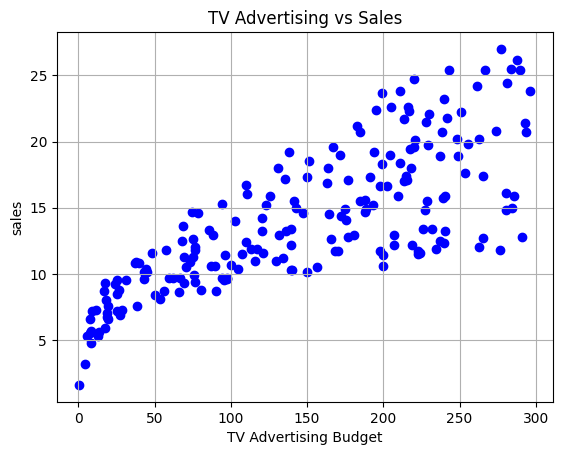

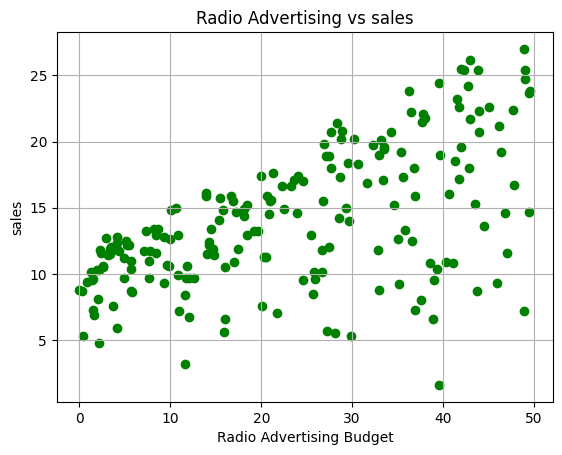

In [ ]:
import matplotlib.pyplot as plt

# TV vs Sales
plt.scatter(df['TV'], df['sales'], color='blue')
plt.title('TV Advertising vs Sales')
plt.xlabel('TV Advertising Budget')
plt.ylabel('sales')
plt.grid(True)
plt.show()

# Radio vs Sales
plt.scatter(df['radio'], df['sales'], color='green')
plt.title('Radio Advertising vs sales')
plt.xlabel('Radio Advertising Budget')
plt.ylabel('sales')
plt.grid(True)
plt.show()


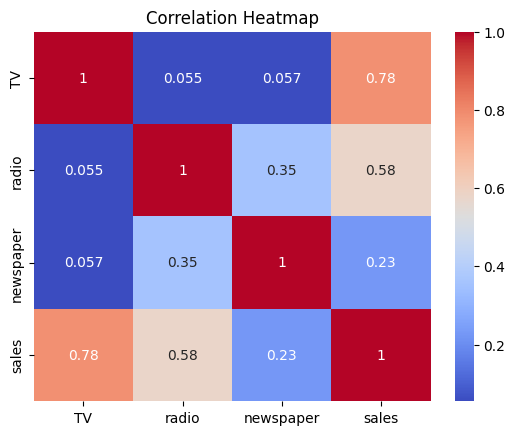

In [ ]:

# Correlation heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [ ]:
# Step 4: Feature Selection
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

# Step 5: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Create and train model
model = LinearRegression()
model.fit(X_train, y_train)

# Model coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: 2.979067338122629
Coefficients: [0.04472952 0.18919505 0.00276111]


In [ ]:
# Predict on test set
y_pred = model.predict(X_test)

# Compare actual vs predicted
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(results.head())


     Actual  Predicted
95     16.9  16.408024
15     22.4  20.889882
30     21.4  21.553843
158     7.3  10.608503
128    24.7  22.112373


In [ ]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)


Mean Squared Error: 3.1740973539761033
Root Mean Squared Error: 1.78159966153345
R² Score: 0.899438024100912


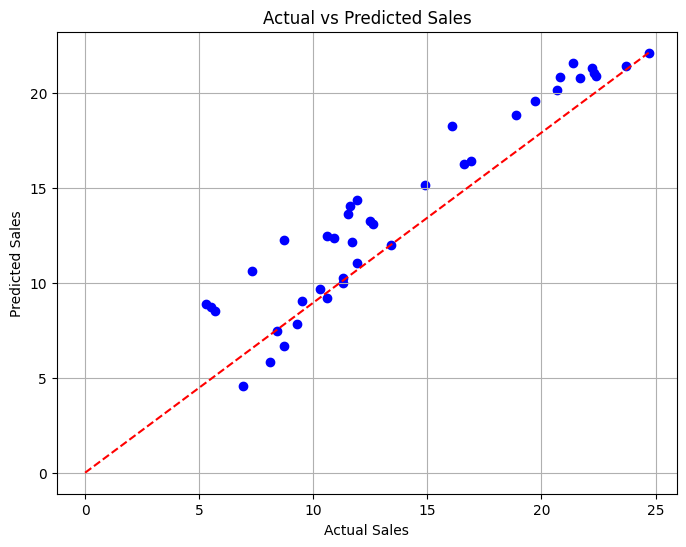

In [ ]:
# Visualize prediction vs actual
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([0, max(y_test)], [0, max(y_pred)], color='red', linestyle='--')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.grid()
plt.show()
